# SPY — Exploratory Data Analysis
**7 Best Day-Trading Indicators**
1. MACD — trend / momentum
2. RSI — momentum oscillator
3. Stochastic Oscillator — momentum
4. Bollinger Bands — volatility
5. On-Balance Volume (OBV) — volume
6. Average Directional Index (ADX) — trend strength
7. Parabolic SAR (PSAR) — trend direction / stop

Library: [`ta`](https://technical-analysis-library-in-python.readthedocs.io/)

In [18]:
# !pip install ta
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ta

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'grid.color': '#21262d',
    'grid.linestyle': '--',        'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})
# print('ta version:', ta.__version__)

## 1 — Load Raw Data

In [19]:
df = pd.read_csv('Data/raw/SPY.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df[['date','open','high','low','close','volume']]
print(f'Shape: {df.shape}')
print(f'Date range: {df.date.min().date()}  →  {df.date.max().date()}')
df.tail()

Shape: (4023, 6)
Date range: 2010-01-04  →  2025-12-30


,date,open,high,low,close,volume
4018,2025-12-23,682.057268,686.325640,682.007416,686.086304,64840000
4019,2025-12-24,686.076320,688.948481,685.926705,688.499695,39445600
4020,2025-12-26,688.758989,689.776169,687.392725,688.429871,41613300
4021,2025-12-29,685.667409,687.322922,684.201442,685.976562,62559500
4022,2025-12-30,685.577720,686.684682,684.710094,685.138916,47160700


In [20]:
df[['open','high','low','close','volume']].describe().round(2)

,open,high,low,close,volume
count,4023.00,4023.00,4023.00,4023.00,4.023000e+03
mean,267.92,269.36,266.35,267.97,1.093688e+08
std,155.46,156.25,154.57,155.48,6.797125e+07
min,77.84,78.07,76.34,77.15,2.027000e+07
25%,146.32,146.67,145.84,146.22,6.523535e+07
50%,227.96,230.95,226.07,227.70,8.943310e+07
75%,385.72,388.48,383.57,386.30,1.328858e+08
max,688.76,689.78,687.39,688.50,7.178287e+08


In [21]:
print('Missing values:'); print(df.isnull().sum())

Missing values:
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


## 1.5 — OHLCV Visual Overview

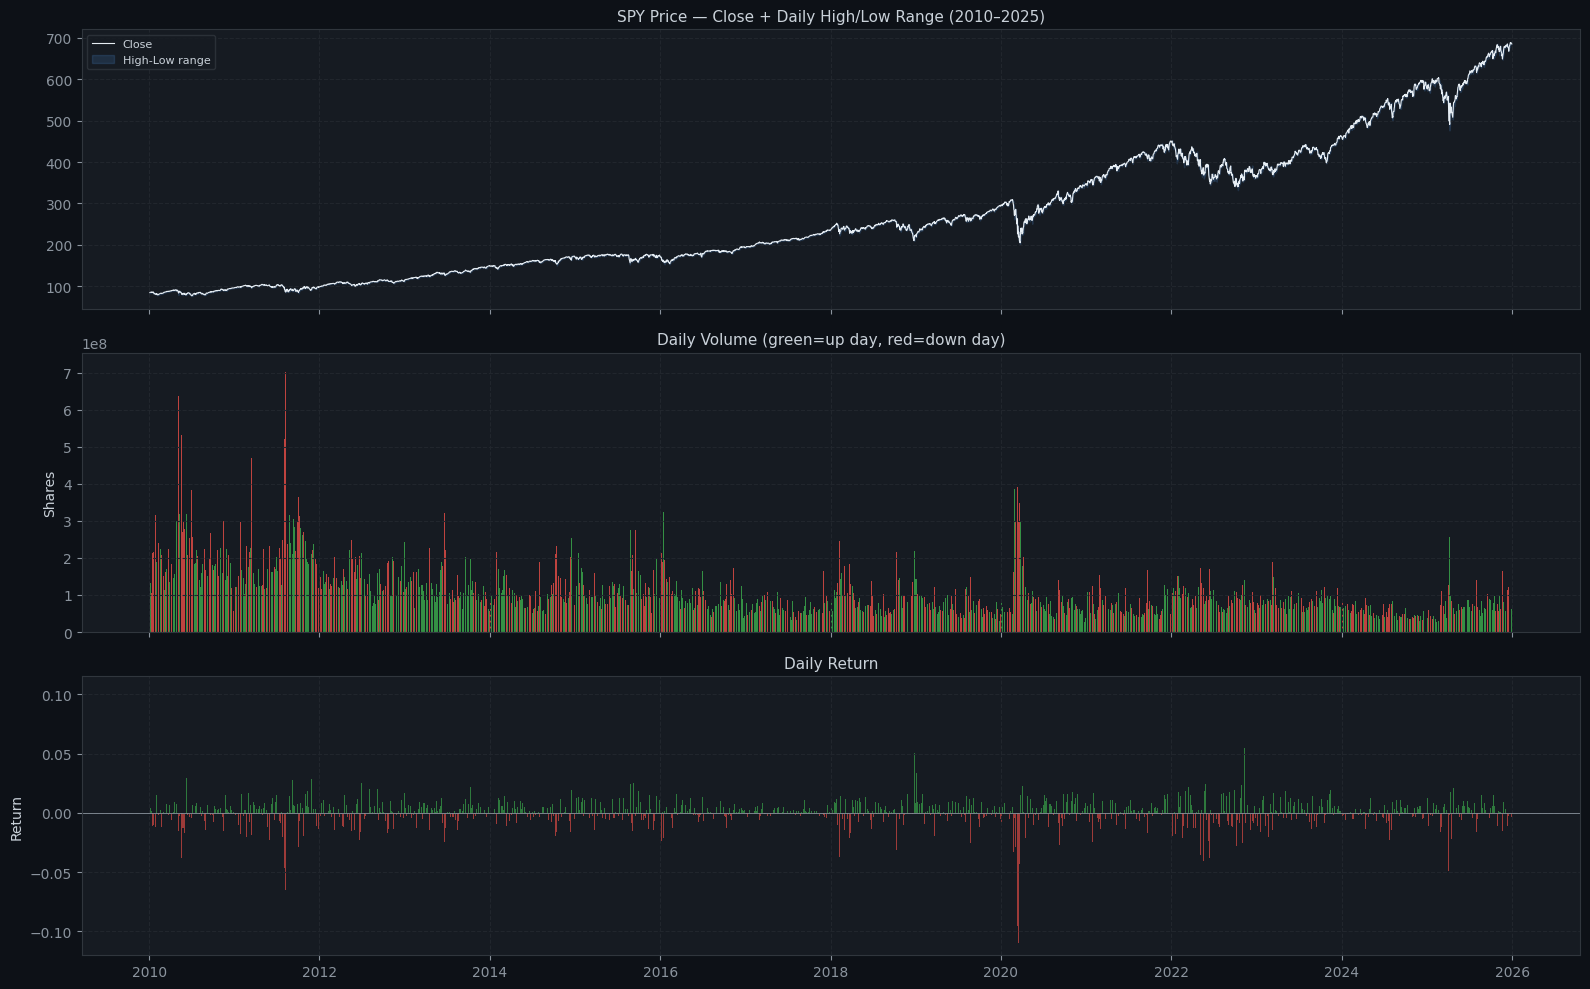

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Price (OHLC via candlestick-style: just close + range fill)
axes[0].plot(df['date'], df['close'], color='#e6edf3', lw=0.8, label='Close')
axes[0].fill_between(df['date'], df['low'], df['high'], alpha=0.15, color='#58a6ff', label='High-Low range')
axes[0].set_title('SPY Price — Close + Daily High/Low Range (2010–2025)', fontsize=11)
axes[0].legend(fontsize=8); axes[0].grid(True)

# Volume
vol_colors = ['#3fb950' if c >= o else '#f85149'
              for c, o in zip(df['close'], df['open'])]
axes[1].bar(df['date'], df['volume'], color=vol_colors, alpha=0.75, width=1)
axes[1].set_title('Daily Volume (green=up day, red=down day)', fontsize=11)
axes[1].set_ylabel('Shares'); axes[1].grid(True)

# Daily return
ret = df['close'].pct_change()
axes[2].bar(df['date'], ret, color=['#3fb950' if r >= 0 else '#f85149' for r in ret.fillna(0)],
            alpha=0.6, width=1)
axes[2].axhline(0, color='#8b949e', lw=0.6)
axes[2].set_title('Daily Return', fontsize=11)
axes[2].set_ylabel('Return'); axes[2].grid(True)

plt.tight_layout(); plt.show()


## 1.6 — Statistical Checks on OHLCV

Tests run:
1. **Stationarity** — ADF (Augmented Dickey-Fuller) + KPSS on price levels and returns  
2. **Normality** — Jarque-Bera + Shapiro-Wilk on daily returns  
3. **Serial correlation** — ACF / PACF of returns and squared returns (volatility clustering)  
4. **Rolling statistics** — visual non-stationarity check on close  
5. **Distribution shape** — QQ plot + fat-tail comparison  
6. **OHLCV cross-correlations**  


### 1.6.1 Stationarity Tests — ADF & KPSS

In [25]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(series, name):
    r = adfuller(series.dropna(), autolag='AIC')
    return {'Series': name, 'ADF stat': round(r[0],4),
            'p-value': round(r[1],4),
            'Lags used': r[2], 'Obs': r[3],
            'Crit 1%': round(r[4]['1%'],3),
            'Crit 5%': round(r[4]['5%'],3),
            'Stationary (5%)?': 'YES' if r[1] < 0.05 else 'NO'}

def kpss_test(series, name):
    # KPSS H0 = stationary; reject H0 => non-stationary
    r = kpss(series.dropna(), regression='c', nlags='auto')
    return {'Series': name, 'KPSS stat': round(r[0],4),
            'p-value': round(r[1],4),
            'Crit 5%': round(r[3]['5%'],3),
            'Stationary (5%)?': 'YES' if r[0] < r[3]['5%'] else 'NO'}

ret = df['close'].pct_change().dropna()
log_ret = np.log(df['close']).diff().dropna()

series_map = {
    'Close (level)':      df['close'],
    'Log(Close) (level)': np.log(df['close']),
    'Daily return':       ret,
    'Log return':         log_ret,
    'Volume':             df['volume'],
    'High-Low range':     (df['high'] - df['low']),
}

adf_rows  = [adf_test(s, n)  for n, s in series_map.items()]
kpss_rows = [kpss_test(s, n) for n, s in series_map.items()]

print('=== ADF Test  (H₀: unit root present → non-stationary) ===')
print(pd.DataFrame(adf_rows).to_string(index=False))
print()
print('=== KPSS Test (H₀: series is stationary) ===')
print(pd.DataFrame(kpss_rows).to_string(index=False))


=== ADF Test  (H₀: unit root present → non-stationary) ===
            Series  ADF stat  p-value  Lags used  Obs  Crit 1%  Crit 5% Stationary (5%)?
     Close (level)    2.0747   0.9988         29 3993   -3.432   -2.862               NO
Log(Close) (level)   -0.1948   0.9391         27 3995   -3.432   -2.862               NO
      Daily return  -13.8509   0.0000         26 3995   -3.432   -2.862              YES
        Log return  -13.7306   0.0000         26 3995   -3.432   -2.862              YES
            Volume   -4.7912   0.0001         28 3994   -3.432   -2.862              YES
    High-Low range   -4.3439   0.0004         31 3991   -3.432   -2.862              YES

=== KPSS Test (H₀: series is stationary) ===
            Series  KPSS stat  p-value  Crit 5% Stationary (5%)?
     Close (level)     9.2362     0.01    0.463               NO
Log(Close) (level)     9.9645     0.01    0.463               NO
      Daily return     0.0347     0.10    0.463              YES
        Log 

/var/folders/gd/z5t4ptgn33366gk7rzbftg300000gn/T/ipykernel_39102/1568698925.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  r = kpss(series.dropna(), regression='c', nlags='auto')
/var/folders/gd/z5t4ptgn33366gk7rzbftg300000gn/T/ipykernel_39102/1568698925.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  r = kpss(series.dropna(), regression='c', nlags='auto')
/var/folders/gd/z5t4ptgn33366gk7rzbftg300000gn/T/ipykernel_39102/1568698925.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(series.dropna(), regression='c', nlags='auto')
/var/folders/gd/z5t4ptgn33366gk7rzbftg300000gn/T/ipykernel_39102/1568698925.

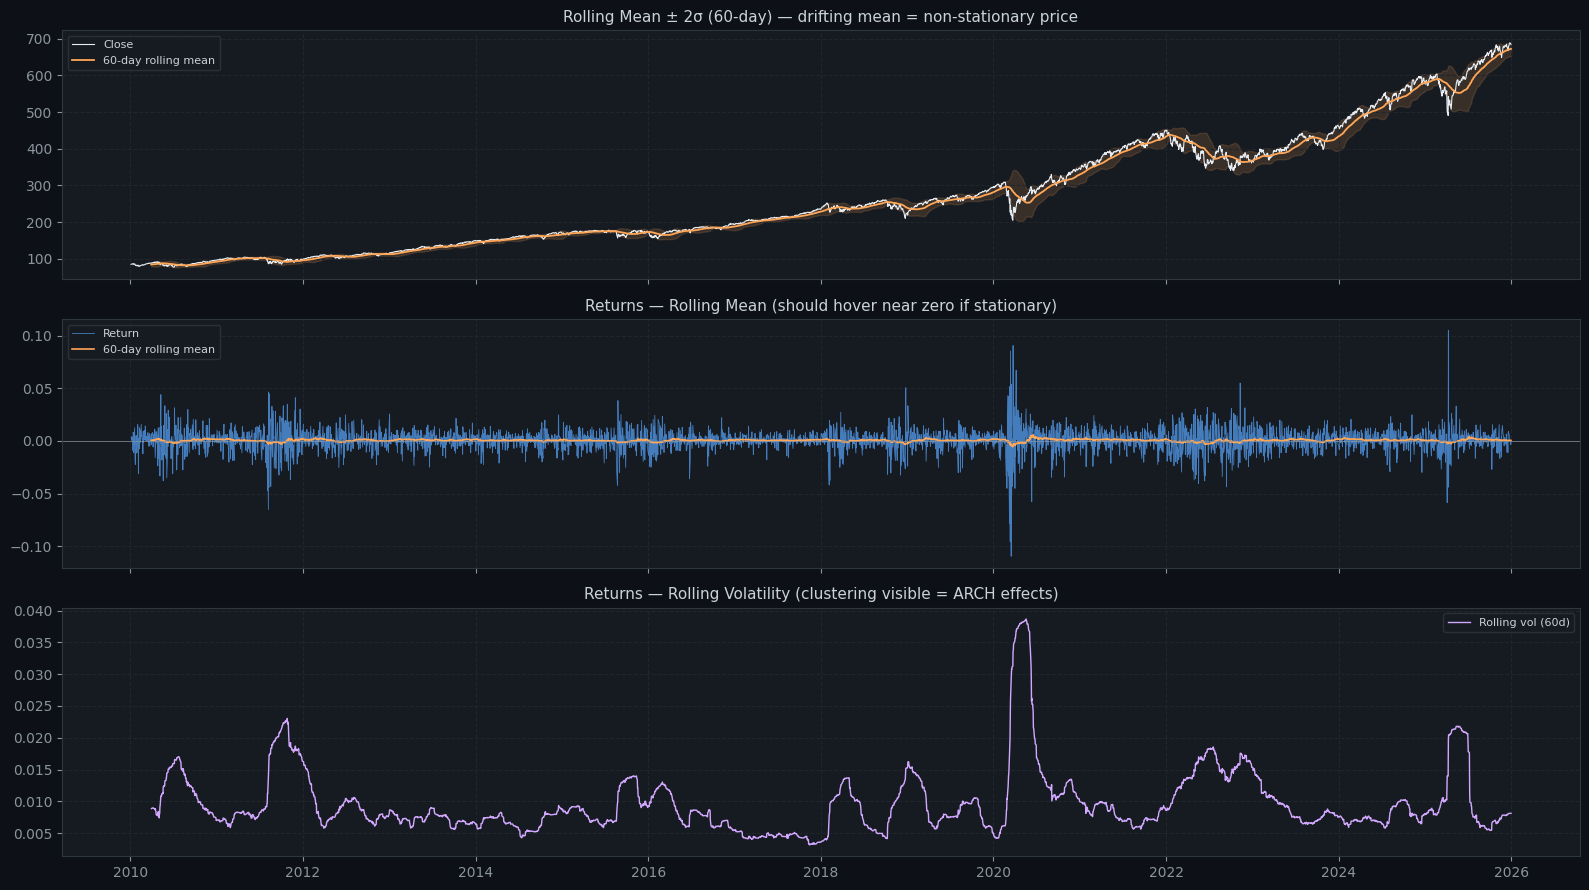

In [26]:
# Visual: rolling mean & std of close price
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

roll = df['close'].rolling(60)
axes[0].plot(df['date'], df['close'],       color='#e6edf3', lw=0.8, label='Close')
axes[0].plot(df['date'], roll.mean(),       color='#ffa657', lw=1.3, label='60-day rolling mean')
axes[0].fill_between(df['date'],
                     roll.mean() - 2*roll.std(),
                     roll.mean() + 2*roll.std(),
                     alpha=0.15, color='#ffa657')
axes[0].set_title('Rolling Mean ± 2σ (60-day) — drifting mean = non-stationary price', fontsize=11)
axes[0].legend(fontsize=8); axes[0].grid(True)

ret = df['close'].pct_change()
roll_r = ret.rolling(60)
axes[1].plot(df['date'], ret,               color='#58a6ff', lw=0.6, alpha=0.7, label='Return')
axes[1].plot(df['date'], roll_r.mean(),     color='#ffa657', lw=1.2, label='60-day rolling mean')
axes[1].axhline(0, color='#8b949e', lw=0.5)
axes[1].set_title('Returns — Rolling Mean (should hover near zero if stationary)', fontsize=11)
axes[1].legend(fontsize=8); axes[1].grid(True)

axes[2].plot(df['date'], roll_r.std(),      color='#d2a8ff', lw=1.0, label='Rolling vol (60d)')
axes[2].set_title('Returns — Rolling Volatility (clustering visible = ARCH effects)', fontsize=11)
axes[2].legend(fontsize=8); axes[2].grid(True)

plt.tight_layout(); plt.show()


### 1.6.2 Normality Tests on Daily Returns

In [27]:
from scipy import stats

ret = df['close'].pct_change().dropna()

jb_stat, jb_p = stats.jarque_bera(ret)
sw_stat, sw_p = stats.shapiro(ret.sample(min(5000, len(ret)), random_state=42))
_, ks_p        = stats.kstest(ret, 'norm', args=(ret.mean(), ret.std()))
kurt           = float(ret.kurt())   # excess kurtosis
skew           = float(ret.skew())

print(f'=== Normality Tests on SPY Daily Returns ===')
print(f'  N observations : {len(ret):,}')
print(f'  Mean           : {ret.mean()*100:.4f}%')
print(f'  Std dev        : {ret.std()*100:.4f}%')
print(f'  Skewness       : {skew:.4f}  (0 = symmetric)')
print(f'  Excess kurtosis: {kurt:.4f}  (0 = normal, >0 = fat tails)')
print()
print(f'  Jarque-Bera    : stat={jb_stat:.2f},  p={jb_p:.2e}  →  {"NOT normal" if jb_p<0.05 else "Normal"}')
print(f'  Shapiro-Wilk   : stat={sw_stat:.4f}, p={sw_p:.2e}  →  {"NOT normal" if sw_p<0.05 else "Normal"}')
print(f'  KS test        : p={ks_p:.2e}                →  {"NOT normal" if ks_p<0.05 else "Normal"}')


=== Normality Tests on SPY Daily Returns ===
  N observations : 4,022
  Mean           : 0.0579%
  Std dev        : 1.0842%
  Skewness       : -0.3350  (0 = symmetric)
  Excess kurtosis: 12.1179  (0 = normal, >0 = fat tails)

  Jarque-Bera    : stat=24616.54,  p=0.00e+00  →  NOT normal
  Shapiro-Wilk   : stat=0.8957, p=4.49e-46  →  NOT normal
  KS test        : p=1.12e-34                →  NOT normal


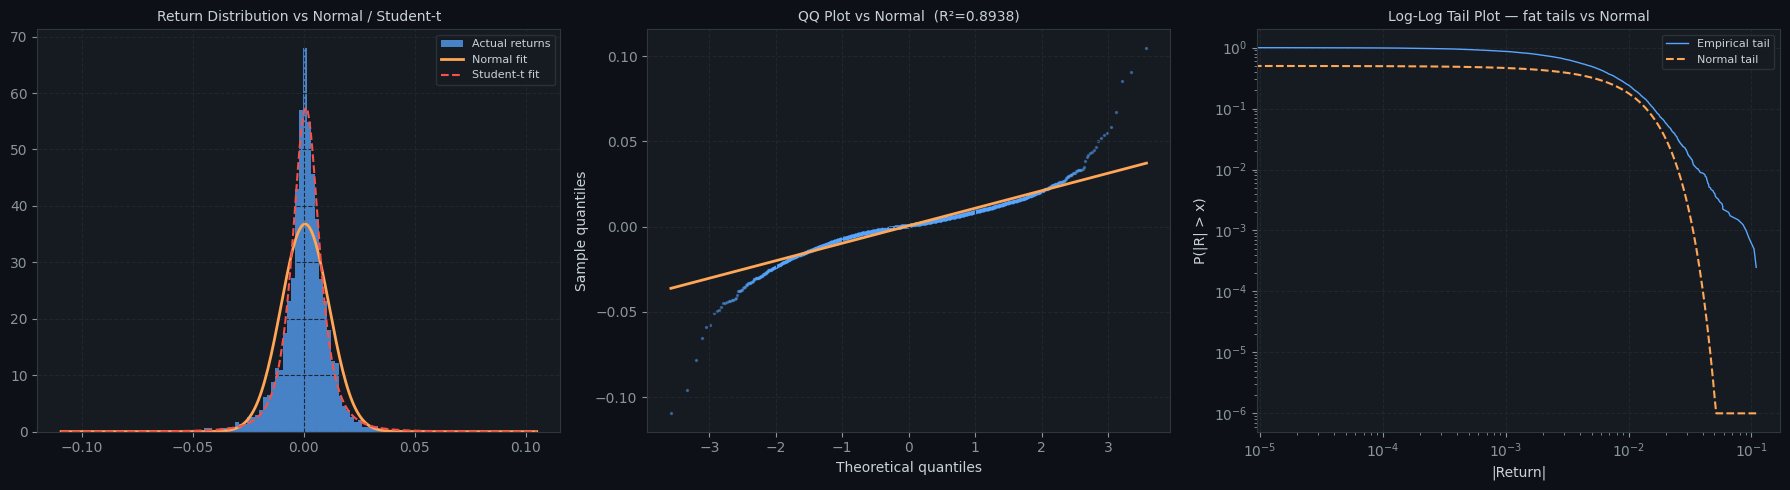

In [28]:
from scipy import stats

ret = df['close'].pct_change().dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram vs normal
x = np.linspace(ret.min(), ret.max(), 300)
axes[0].hist(ret, bins=120, density=True, color='#58a6ff', alpha=0.75, label='Actual returns')
axes[0].plot(x, stats.norm.pdf(x, ret.mean(), ret.std()),
             color='#ffa657', lw=2, label='Normal fit')
axes[0].plot(x, stats.t.pdf(x, *stats.t.fit(ret)),
             color='#f85149', lw=1.5, ls='--', label='Student-t fit')
axes[0].set_title('Return Distribution vs Normal / Student-t', fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(True)

# QQ plot
(osm, osr), (slope, intercept, r) = stats.probplot(ret, dist='norm')
axes[1].scatter(osm, osr, s=2, alpha=0.4, color='#58a6ff')
axes[1].plot(osm, slope*np.array(osm)+intercept, color='#ffa657', lw=2)
axes[1].set_title(f'QQ Plot vs Normal  (R²={r**2:.4f})', fontsize=10)
axes[1].set_xlabel('Theoretical quantiles'); axes[1].set_ylabel('Sample quantiles')
axes[1].grid(True)

# Log-scale tail plot
ret_sorted = np.sort(np.abs(ret.values))[::-1]
rank = np.arange(1, len(ret_sorted)+1) / len(ret_sorted)
axes[2].loglog(ret_sorted, rank, color='#58a6ff', lw=1, label='Empirical tail')
norm_tail = 1 - stats.norm.cdf(ret_sorted, 0, ret.std())
axes[2].loglog(ret_sorted, np.maximum(norm_tail, 1e-6), color='#ffa657',
               lw=1.5, ls='--', label='Normal tail')
axes[2].set_title('Log-Log Tail Plot — fat tails vs Normal', fontsize=10)
axes[2].set_xlabel('|Return|'); axes[2].set_ylabel('P(|R| > x)')
axes[2].legend(fontsize=8); axes[2].grid(True)

plt.tight_layout(); plt.show()


### 1.6.3 Serial Correlation — ACF & PACF

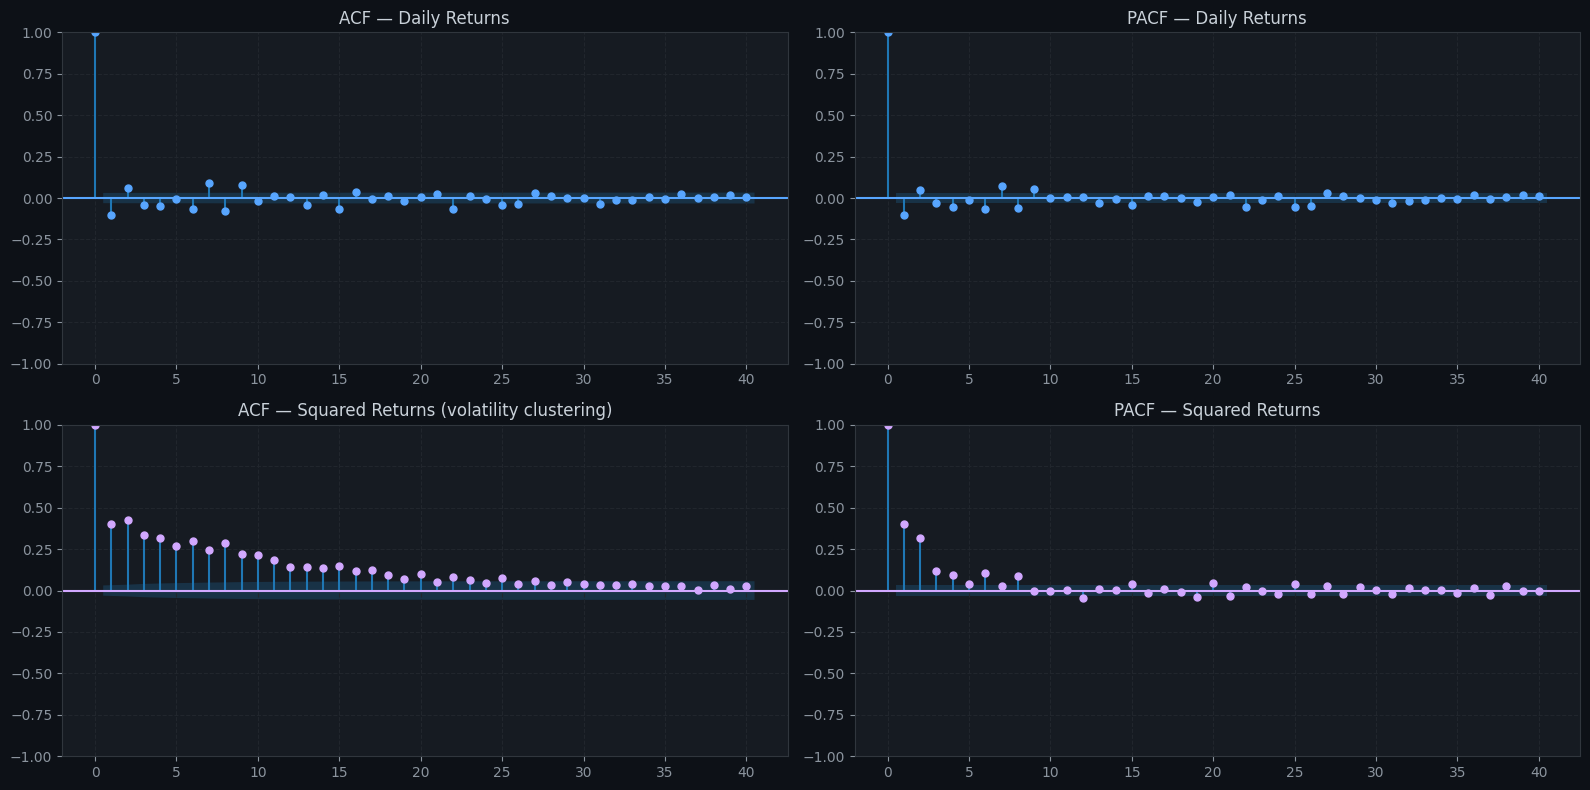

=== Ljung-Box test on Returns (H₀: no autocorrelation) ===
       lb_stat     lb_pvalue
5    74.293262  1.306418e-14
10  174.348239  3.485415e-32
20  210.205245  1.065945e-33

=== Ljung-Box test on Squared Returns (H₀: no ARCH effects) ===
        lb_stat  lb_pvalue
5   2528.211593        0.0
10  3843.730703        0.0
20  4520.521115        0.0


In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

ret    = df['close'].pct_change().dropna()
ret_sq = ret**2  # squared returns for volatility clustering

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
plot_acf( ret,    lags=40, ax=axes[0,0], color='#58a6ff', title='ACF — Daily Returns')
plot_pacf(ret,    lags=40, ax=axes[0,1], color='#58a6ff', title='PACF — Daily Returns')
plot_acf( ret_sq, lags=40, ax=axes[1,0], color='#d2a8ff', title='ACF — Squared Returns (volatility clustering)')
plot_pacf(ret_sq, lags=40, ax=axes[1,1], color='#d2a8ff', title='PACF — Squared Returns')
for ax in axes.flat:
    ax.grid(True)
    ax.set_facecolor('#161b22')
plt.tight_layout(); plt.show()

# Ljung-Box test for autocorrelation
lb_ret = acorr_ljungbox(ret,    lags=[5, 10, 20], return_df=True)
lb_sq  = acorr_ljungbox(ret_sq, lags=[5, 10, 20], return_df=True)
print('=== Ljung-Box test on Returns (H₀: no autocorrelation) ===')
print(lb_ret.to_string())
print()
print('=== Ljung-Box test on Squared Returns (H₀: no ARCH effects) ===')
print(lb_sq.to_string())


### 1.6.4 OHLCV Feature Correlations & Distributions

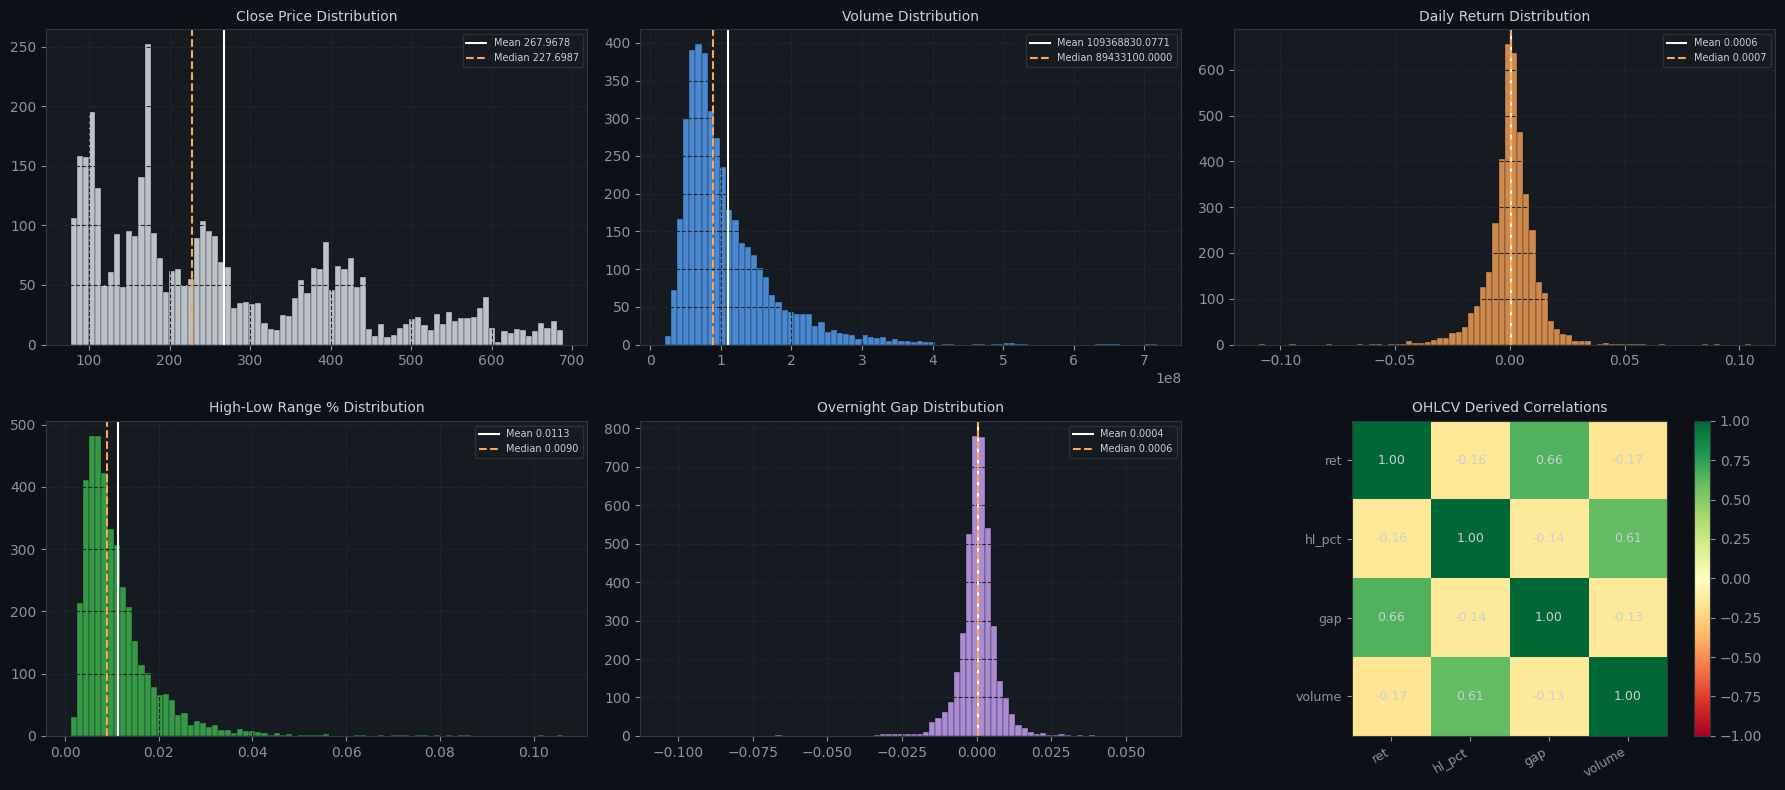

In [30]:
ohlcv = df[['open','high','low','close','volume']].copy()
ohlcv['ret']    = ohlcv['close'].pct_change()
ohlcv['hl_pct'] = (ohlcv['high'] - ohlcv['low']) / ohlcv['close']   # daily range %
ohlcv['gap']    = (ohlcv['open'] - ohlcv['close'].shift(1)) / ohlcv['close'].shift(1)  # overnight gap

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

cols = ['close','volume','ret','hl_pct','gap']
titles = ['Close Price','Volume','Daily Return','High-Low Range %','Overnight Gap']
colors = ['#e6edf3','#58a6ff','#ffa657','#3fb950','#d2a8ff']

for ax, col, title, color in zip(axes.flat[:5], cols, titles, colors):
    data = ohlcv[col].dropna()
    ax.hist(data, bins=80, color=color, alpha=0.80, edgecolor='#0d1117', lw=0.3)
    ax.axvline(data.mean(),   color='white',   lw=1.5, ls='-',  label=f'Mean {data.mean():.4f}')
    ax.axvline(data.median(), color='#ffa657', lw=1.5, ls='--', label=f'Median {data.median():.4f}')
    ax.set_title(f'{title} Distribution', fontsize=10)
    ax.legend(fontsize=7); ax.grid(True)

# Correlation heatmap of derived stats
cm = ohlcv[['ret','hl_pct','gap','volume']].dropna().corr()
im = axes[1,2].imshow(cm, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1,2].set_xticks(range(4)); axes[1,2].set_yticks(range(4))
axes[1,2].set_xticklabels(cm.columns, rotation=30, ha='right', fontsize=9)
axes[1,2].set_yticklabels(cm.columns, fontsize=9)
for i in range(4):
    for j in range(4):
        axes[1,2].text(j, i, f'{cm.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9)
axes[1,2].set_title('OHLCV Derived Correlations', fontsize=10)
plt.colorbar(im, ax=axes[1,2])

plt.tight_layout(); plt.show()


In [31]:
# Summary table
ret    = df['close'].pct_change().dropna()
hl_pct = ((df['high'] - df['low']) / df['close']).dropna()
gap    = ((df['open'] - df['close'].shift(1)) / df['close'].shift(1)).dropna()

rows = []
for name, s in [('Close',df['close']),('Open',df['open']),('High',df['high']),
                ('Low',df['low']),('Volume',df['volume']),
                ('Daily Return',ret),('HL Range %',hl_pct),('Overnight Gap',gap)]:
    s = s.dropna()
    rows.append({
        'Series': name, 'Mean': round(s.mean(),4), 'Std': round(s.std(),4),
        'Min': round(s.min(),4), 'Max': round(s.max(),4),
        'Skew': round(s.skew(),3), 'Kurt': round(s.kurt(),3),
        'Missing': s.isna().sum()
    })

print('=== OHLCV + Derived Series — Full Stats ===')
print(pd.DataFrame(rows).to_string(index=False))


=== OHLCV + Derived Series — Full Stats ===
       Series         Mean          Std           Min          Max   Skew   Kurt  Missing
        Close 2.679678e+02 1.554802e+02  7.714890e+01 6.884997e+02  0.823 -0.274        0
         Open 2.679186e+02 1.554579e+02  7.783580e+01 6.887590e+02  0.824 -0.272        0
         High 2.693564e+02 1.562466e+02  7.806980e+01 6.897762e+02  0.820 -0.284        0
          Low 2.663491e+02 1.545710e+02  7.634110e+01 6.873927e+02  0.826 -0.263        0
       Volume 1.093688e+08 6.797125e+07  2.027000e+07 7.178287e+08  2.494 10.889        0
 Daily Return 6.000000e-04 1.080000e-02 -1.094000e-01 1.050000e-01 -0.335 12.118        0
   HL Range % 1.130000e-02 8.400000e-03  1.200000e-03 1.063000e-01  3.398 20.785        0
Overnight Gap 4.000000e-04 6.900000e-03 -1.045000e-01 6.040000e-02 -1.593 27.502        0


## 2 — Compute All 7 Indicators

In [32]:
# 1. MACD
macd_ind          = ta.trend.MACD(close=df['close'], window_slow=26, window_fast=12, window_sign=9)
df['macd']        = macd_ind.macd()
df['macd_signal'] = macd_ind.macd_signal()
df['macd_hist']   = macd_ind.macd_diff()

# 2. RSI
df['rsi_14'] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

# 3. Stochastic Oscillator
stoch          = ta.momentum.StochasticOscillator(high=df['high'], low=df['low'], close=df['close'], window=14, smooth_window=3)
df['stoch_k']  = stoch.stoch()
df['stoch_d']  = stoch.stoch_signal()

# 4. Bollinger Bands
bb             = ta.volatility.BollingerBands(close=df['close'], window=20, window_dev=2)
df['bb_upper'] = bb.bollinger_hband()
df['bb_mid']   = bb.bollinger_mavg()
df['bb_lower'] = bb.bollinger_lband()
df['bb_width'] = bb.bollinger_wband()
df['bb_pct']   = bb.bollinger_pband()

# 5. OBV
df['obv'] = ta.volume.OnBalanceVolumeIndicator(close=df['close'], volume=df['volume']).on_balance_volume()

# 6. ADX
adx_ind       = ta.trend.ADXIndicator(high=df['high'], low=df['low'], close=df['close'], window=14)
df['adx']     = adx_ind.adx()
df['adx_pos'] = adx_ind.adx_pos()
df['adx_neg'] = adx_ind.adx_neg()

# 7. Parabolic SAR
psar_ind       = ta.trend.PSARIndicator(high=df['high'], low=df['low'], close=df['close'], step=0.02, max_step=0.2)
df['psar']     = psar_ind.psar()
df['psar_up']  = psar_ind.psar_up()
df['psar_down']= psar_ind.psar_down()

df['ret_1d']   = df['close'].pct_change(1)
df['ret_next'] = df['ret_1d'].shift(-1)

print('Done. New columns:')
print([c for c in df.columns if c not in ['date','open','high','low','close','volume']])

Done. New columns:
['macd', 'macd_signal', 'macd_hist', 'rsi_14', 'stoch_k', 'stoch_d', 'bb_upper', 'bb_mid', 'bb_lower', 'bb_width', 'bb_pct', 'obv', 'adx', 'adx_pos', 'adx_neg', 'psar', 'psar_up', 'psar_down', 'ret_1d', 'ret_next']


## 3 — Indicator Correlation with Next-Day Return

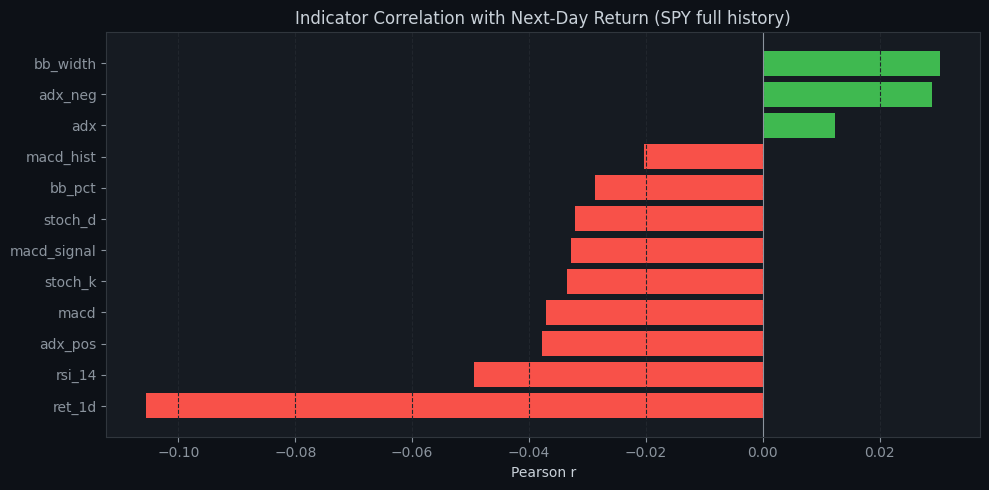

In [33]:
indicator_cols = ['macd','macd_signal','macd_hist','rsi_14','stoch_k','stoch_d',
                  'bb_width','bb_pct','adx','adx_pos','adx_neg','ret_1d']
corr = df[indicator_cols + ['ret_next']].dropna().corr()['ret_next'].drop('ret_next').sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#f85149' if v < 0 else '#3fb950' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='#8b949e', lw=0.8)
ax.set_title('Indicator Correlation with Next-Day Return (SPY full history)', fontsize=12)
ax.set_xlabel('Pearson r'); ax.grid(axis='x')
plt.tight_layout(); plt.show()

## 4 — Full Dashboard: Last 252 Trading Days

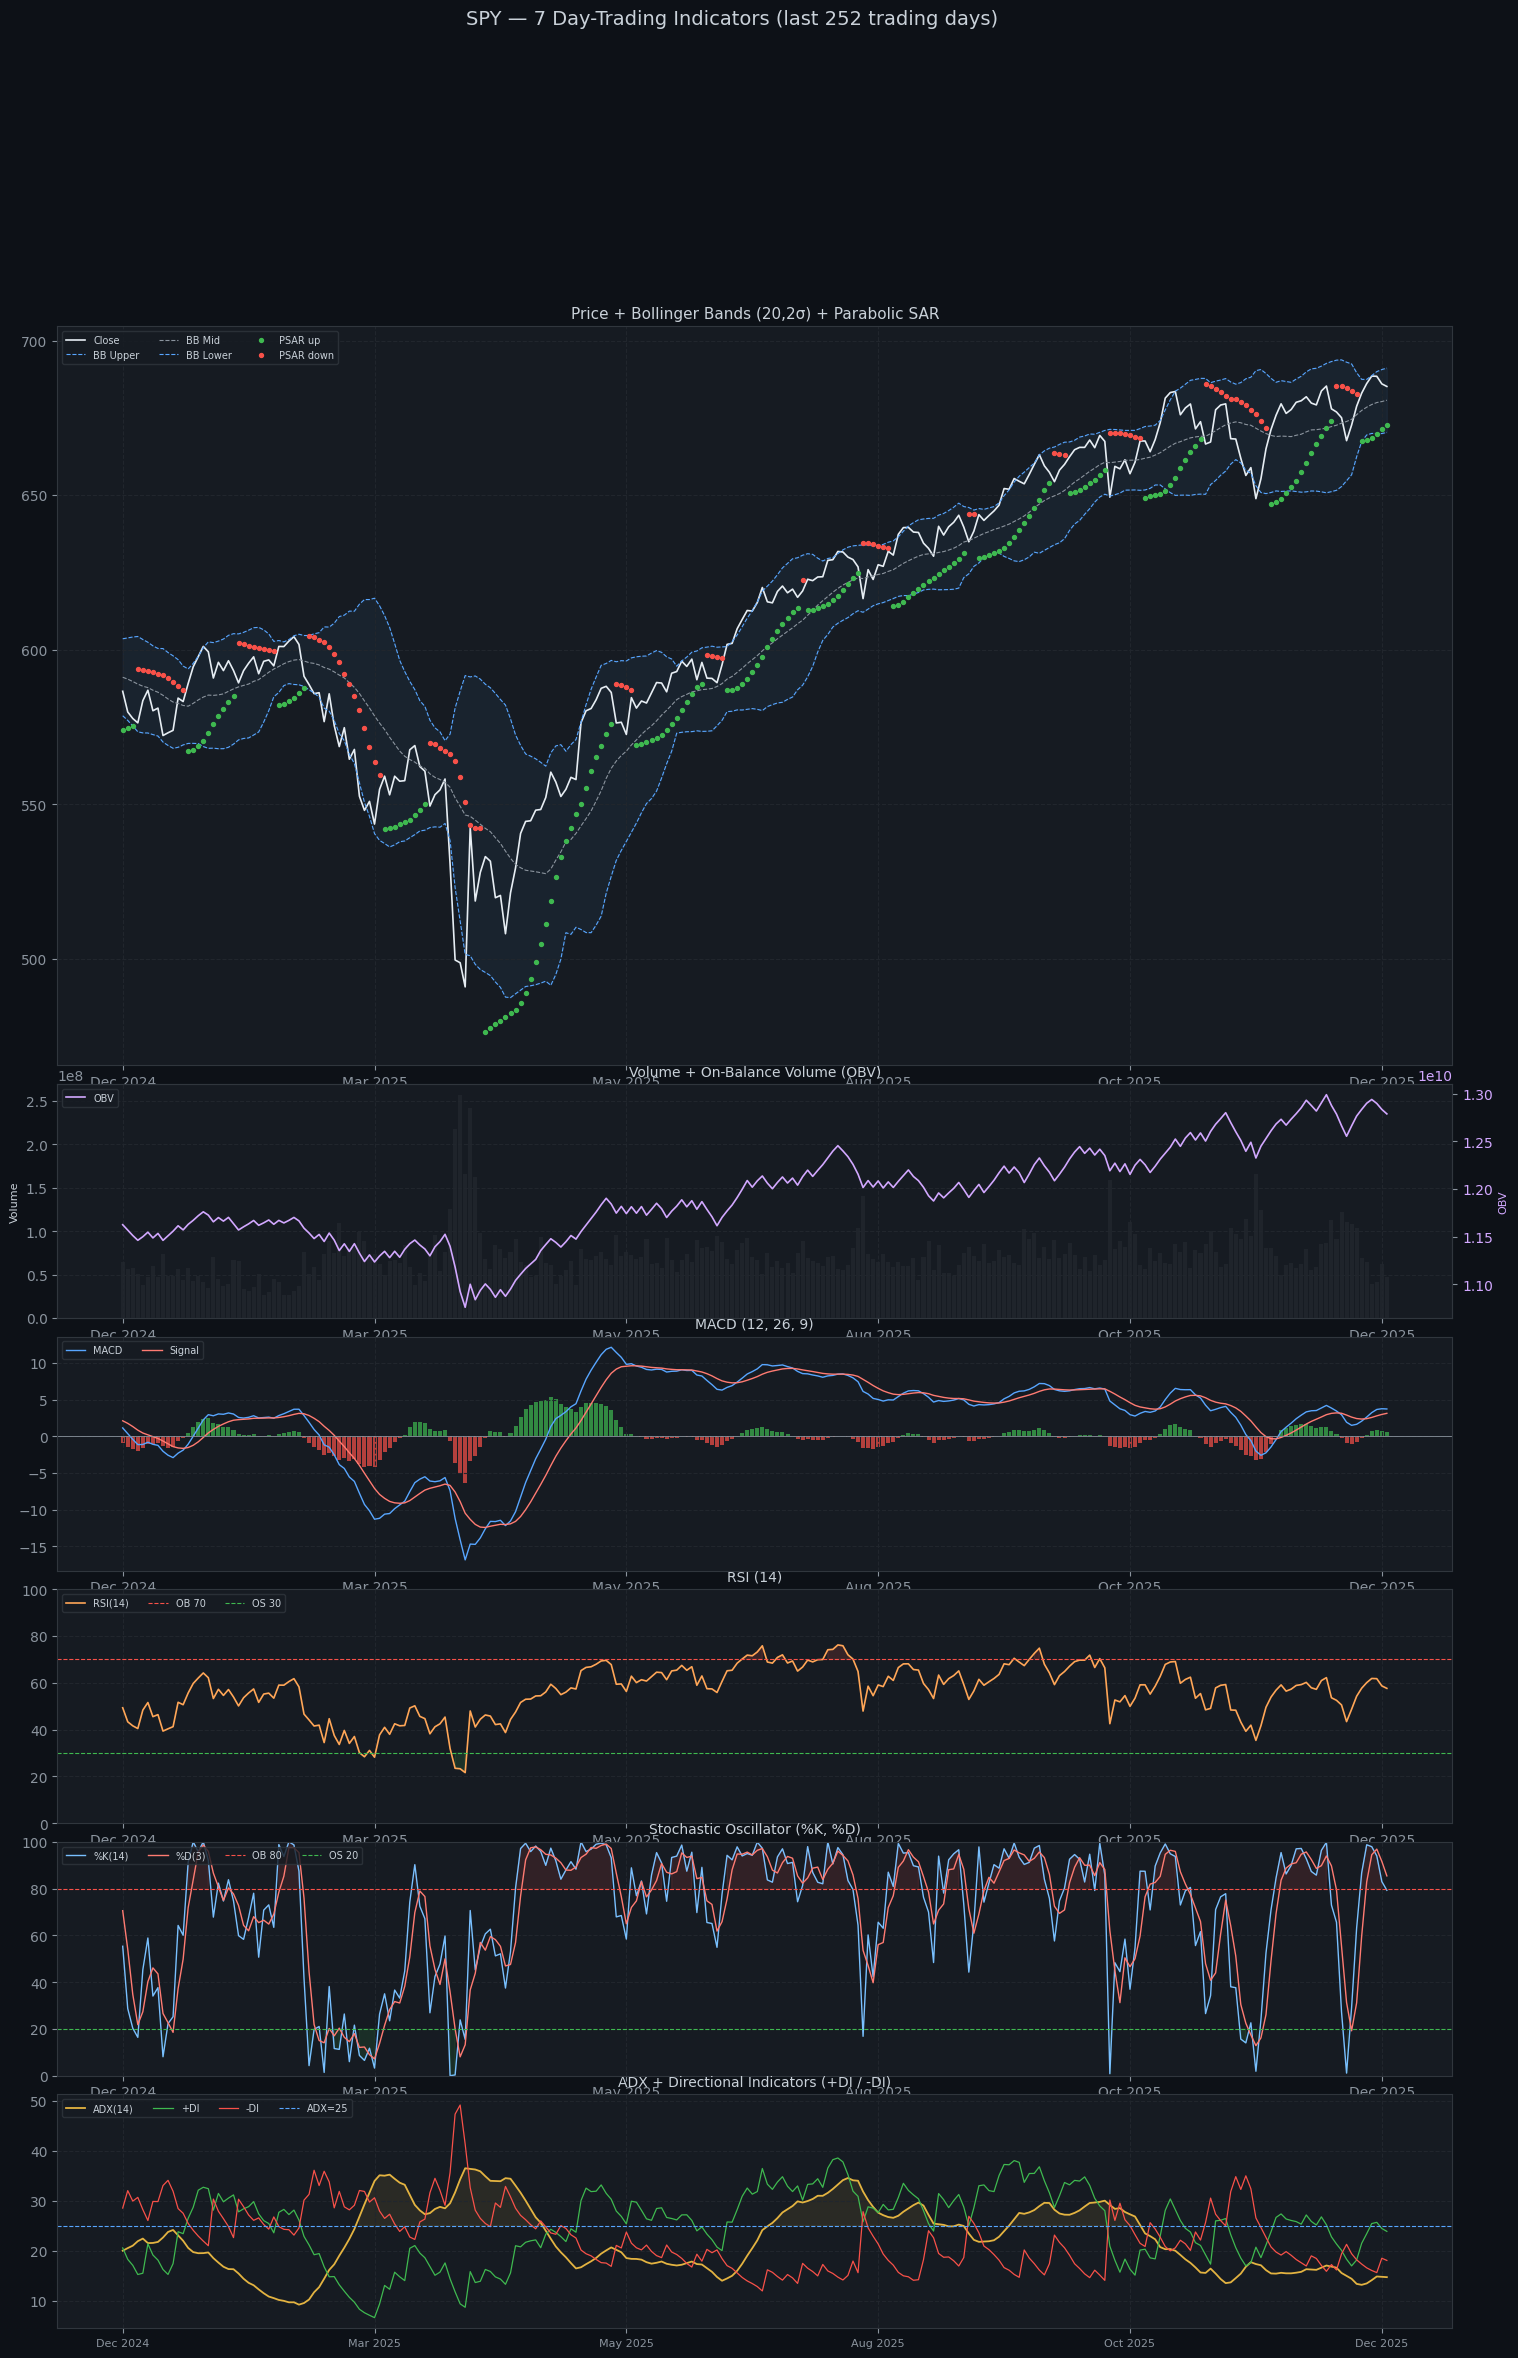

In [34]:
view = df.dropna(subset=['macd','rsi_14','stoch_k','adx','obv']).tail(252).reset_index(drop=True)
idx  = range(len(view))
dates= view['date'].dt.strftime('%b %Y')
tick_pos    = list(range(0, len(view), 50))
tick_labels = [dates.iloc[i] for i in tick_pos]

fig = plt.figure(figsize=(18, 26))
gs  = gridspec.GridSpec(8, 1, figure=fig, hspace=0.08)

# Panel 0: Price + BB + PSAR
ax0 = fig.add_subplot(gs[0:3, 0])
ax0.plot(idx, view['close'],    color='#e6edf3', lw=1.2, label='Close')
ax0.plot(idx, view['bb_upper'], color='#58a6ff', lw=0.8, ls='--', label='BB Upper')
ax0.plot(idx, view['bb_mid'],   color='#8b949e', lw=0.8, ls='--', label='BB Mid')
ax0.plot(idx, view['bb_lower'], color='#58a6ff', lw=0.8, ls='--', label='BB Lower')
ax0.fill_between(idx, view['bb_upper'], view['bb_lower'], alpha=0.06, color='#58a6ff')
up_m   = view['psar_up'].notna()
down_m = view['psar_down'].notna()
ax0.scatter([i for i,m in zip(idx,up_m)   if m], view.loc[up_m,'psar_up'].values,
            color='#3fb950', s=8, label='PSAR up', zorder=3)
ax0.scatter([i for i,m in zip(idx,down_m) if m], view.loc[down_m,'psar_down'].values,
            color='#f85149', s=8, label='PSAR down', zorder=3)
ax0.set_title('Price + Bollinger Bands (20,2σ) + Parabolic SAR', fontsize=11)
ax0.legend(loc='upper left', fontsize=7, ncol=3); ax0.grid(True)
ax0.set_xticks(tick_pos); ax0.set_xticklabels([])

# Panel 1: Volume + OBV
ax1  = fig.add_subplot(gs[3, 0], sharex=ax0)
ax1v = ax1.twinx()
ax1.bar(idx, view['volume'], color='#21262d', alpha=0.9)
ax1v.plot(idx, view['obv'], color='#d2a8ff', lw=1.2, label='OBV')
ax1.set_ylabel('Volume', fontsize=8)
ax1v.set_ylabel('OBV', fontsize=8, color='#d2a8ff')
ax1v.tick_params(axis='y', labelcolor='#d2a8ff')
ax1v.legend(loc='upper left', fontsize=7)
ax1.set_title('Volume + On-Balance Volume (OBV)', fontsize=10); ax1.grid(True)
ax1.set_xticks(tick_pos); ax1.set_xticklabels([])

# Panel 2: MACD
ax2 = fig.add_subplot(gs[4, 0], sharex=ax0)
h_colors = ['#3fb950' if v>=0 else '#f85149' for v in view['macd_hist']]
ax2.bar(idx, view['macd_hist'], color=h_colors, alpha=0.7)
ax2.plot(idx, view['macd'],        color='#58a6ff', lw=1.0, label='MACD')
ax2.plot(idx, view['macd_signal'], color='#ff7b72', lw=1.0, label='Signal')
ax2.axhline(0, color='#8b949e', lw=0.6)
ax2.set_title('MACD (12, 26, 9)', fontsize=10)
ax2.legend(loc='upper left', fontsize=7, ncol=3); ax2.grid(True)
ax2.set_xticks(tick_pos); ax2.set_xticklabels([])

# Panel 3: RSI
ax3 = fig.add_subplot(gs[5, 0], sharex=ax0)
ax3.plot(idx, view['rsi_14'], color='#ffa657', lw=1.2, label='RSI(14)')
ax3.axhline(70, color='#f85149', lw=0.8, ls='--', label='OB 70')
ax3.axhline(30, color='#3fb950', lw=0.8, ls='--', label='OS 30')
ax3.fill_between(idx, 70, view['rsi_14'], where=(view['rsi_14']>=70), color='#f85149', alpha=0.15)
ax3.fill_between(idx, view['rsi_14'], 30,  where=(view['rsi_14']<=30), color='#3fb950', alpha=0.15)
ax3.set_ylim(0, 100)
ax3.set_title('RSI (14)', fontsize=10)
ax3.legend(loc='upper left', fontsize=7, ncol=3); ax3.grid(True)
ax3.set_xticks(tick_pos); ax3.set_xticklabels([])

# Panel 4: Stochastic
ax4 = fig.add_subplot(gs[6, 0], sharex=ax0)
ax4.plot(idx, view['stoch_k'], color='#79c0ff', lw=1.0, label='%K(14)')
ax4.plot(idx, view['stoch_d'], color='#ff7b72', lw=1.0, label='%D(3)')
ax4.axhline(80, color='#f85149', lw=0.8, ls='--', label='OB 80')
ax4.axhline(20, color='#3fb950', lw=0.8, ls='--', label='OS 20')
ax4.fill_between(idx, 80, view['stoch_k'], where=(view['stoch_k']>=80), color='#f85149', alpha=0.12)
ax4.fill_between(idx, view['stoch_k'], 20,  where=(view['stoch_k']<=20), color='#3fb950', alpha=0.12)
ax4.set_ylim(0, 100)
ax4.set_title('Stochastic Oscillator (%K, %D)', fontsize=10)
ax4.legend(loc='upper left', fontsize=7, ncol=4); ax4.grid(True)
ax4.set_xticks(tick_pos); ax4.set_xticklabels([])

# Panel 5: ADX
ax5 = fig.add_subplot(gs[7, 0], sharex=ax0)
ax5.plot(idx, view['adx'],     color='#e3b341', lw=1.3, label='ADX(14)')
ax5.plot(idx, view['adx_pos'], color='#3fb950', lw=0.9, label='+DI')
ax5.plot(idx, view['adx_neg'], color='#f85149', lw=0.9, label='-DI')
ax5.axhline(25, color='#58a6ff', ls='--', lw=0.8, label='ADX=25')
ax5.fill_between(idx, 25, view['adx'], where=(view['adx']>=25), color='#e3b341', alpha=0.10)
ax5.set_title('ADX + Directional Indicators (+DI / -DI)', fontsize=10)
ax5.legend(loc='upper left', fontsize=7, ncol=4); ax5.grid(True)
ax5.set_xticks(tick_pos); ax5.set_xticklabels(tick_labels, fontsize=8)

fig.suptitle('SPY — 7 Day-Trading Indicators (last 252 trading days)', fontsize=14, y=1.002)
plt.tight_layout(); plt.show()

## 5 — Deep Dives

### 5.1 MACD Crossover Signals

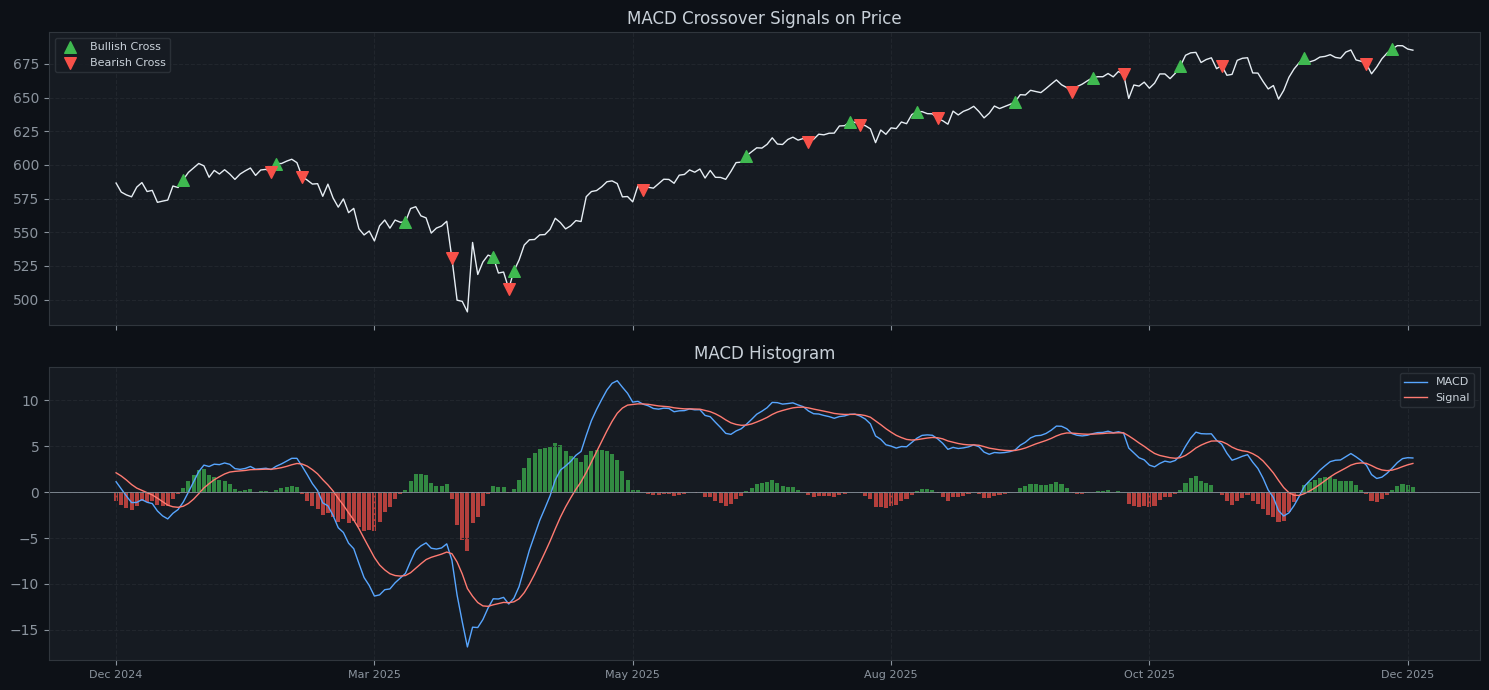

Bullish crossovers: 13  |  Bearish crossovers: 12


In [35]:
v = view.copy()
v['bull_cross'] = (v['macd'] > v['macd_signal']) & (v['macd'].shift(1) <= v['macd_signal'].shift(1))
v['bear_cross'] = (v['macd'] < v['macd_signal']) & (v['macd'].shift(1) >= v['macd_signal'].shift(1))

fig, (ax_p, ax_m) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
ax_p.plot(idx, v['close'], color='#e6edf3', lw=1)
bull_idx = [i for i,m in zip(idx, v['bull_cross']) if m]
bear_idx = [i for i,m in zip(idx, v['bear_cross']) if m]
ax_p.scatter(bull_idx, v.loc[v['bull_cross'],'close'].values, marker='^', color='#3fb950', s=70, zorder=5, label='Bullish Cross')
ax_p.scatter(bear_idx, v.loc[v['bear_cross'],'close'].values, marker='v', color='#f85149', s=70, zorder=5, label='Bearish Cross')
ax_p.set_title('MACD Crossover Signals on Price'); ax_p.legend(fontsize=8); ax_p.grid(True)

h_colors = ['#3fb950' if x>=0 else '#f85149' for x in v['macd_hist']]
ax_m.bar(idx, v['macd_hist'], color=h_colors, alpha=0.7)
ax_m.plot(idx, v['macd'],        color='#58a6ff', lw=1.0, label='MACD')
ax_m.plot(idx, v['macd_signal'], color='#ff7b72', lw=1.0, label='Signal')
ax_m.axhline(0, color='#8b949e', lw=0.6)
ax_m.set_title('MACD Histogram'); ax_m.legend(fontsize=8); ax_m.grid(True)
ax_m.set_xticks(tick_pos); ax_m.set_xticklabels(tick_labels, fontsize=8)
plt.tight_layout(); plt.show()
print(f'Bullish crossovers: {v["bull_cross"].sum()}  |  Bearish crossovers: {v["bear_cross"].sum()}')

### 5.2 RSI Distribution & Zones

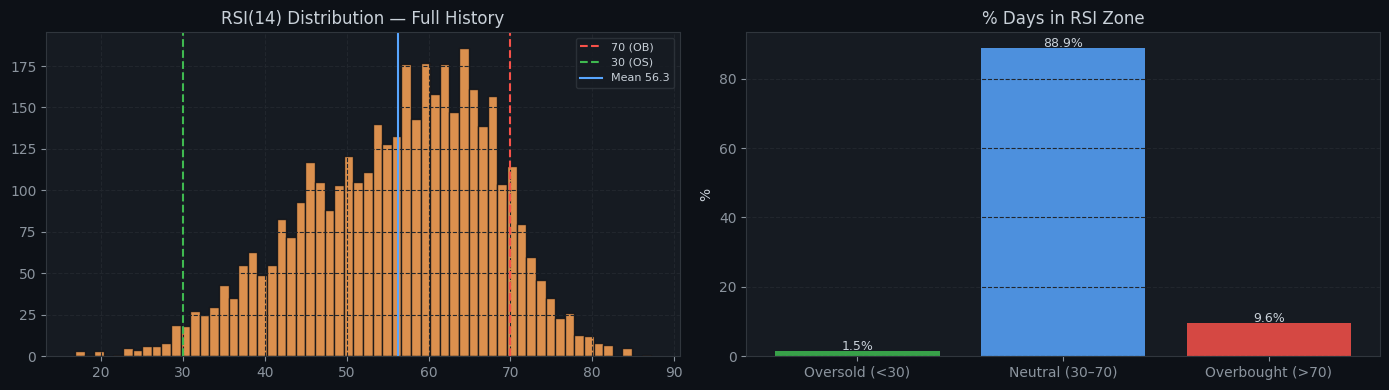

In [36]:
rsi_full = df['rsi_14'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(rsi_full, bins=60, color='#ffa657', edgecolor='#0d1117', alpha=0.85)
axes[0].axvline(70, color='#f85149', lw=1.5, ls='--', label='70 (OB)')
axes[0].axvline(30, color='#3fb950', lw=1.5, ls='--', label='30 (OS)')
axes[0].axvline(rsi_full.mean(), color='#58a6ff', lw=1.5, label=f'Mean {rsi_full.mean():.1f}')
axes[0].set_title('RSI(14) Distribution — Full History'); axes[0].legend(fontsize=8); axes[0].grid(True)
zones = {'Oversold (<30)': (rsi_full<30).mean()*100,
         'Neutral (30–70)': ((rsi_full>=30)&(rsi_full<=70)).mean()*100,
         'Overbought (>70)': (rsi_full>70).mean()*100}
bars = axes[1].bar(zones.keys(), zones.values(), color=['#3fb950','#58a6ff','#f85149'], alpha=0.85)
for bar, val in zip(bars, zones.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%', ha='center', fontsize=9)
axes[1].set_title('% Days in RSI Zone'); axes[1].set_ylabel('%'); axes[1].grid(axis='y')
plt.tight_layout(); plt.show()

### 5.3 Bollinger Bands — Squeeze & Expansion

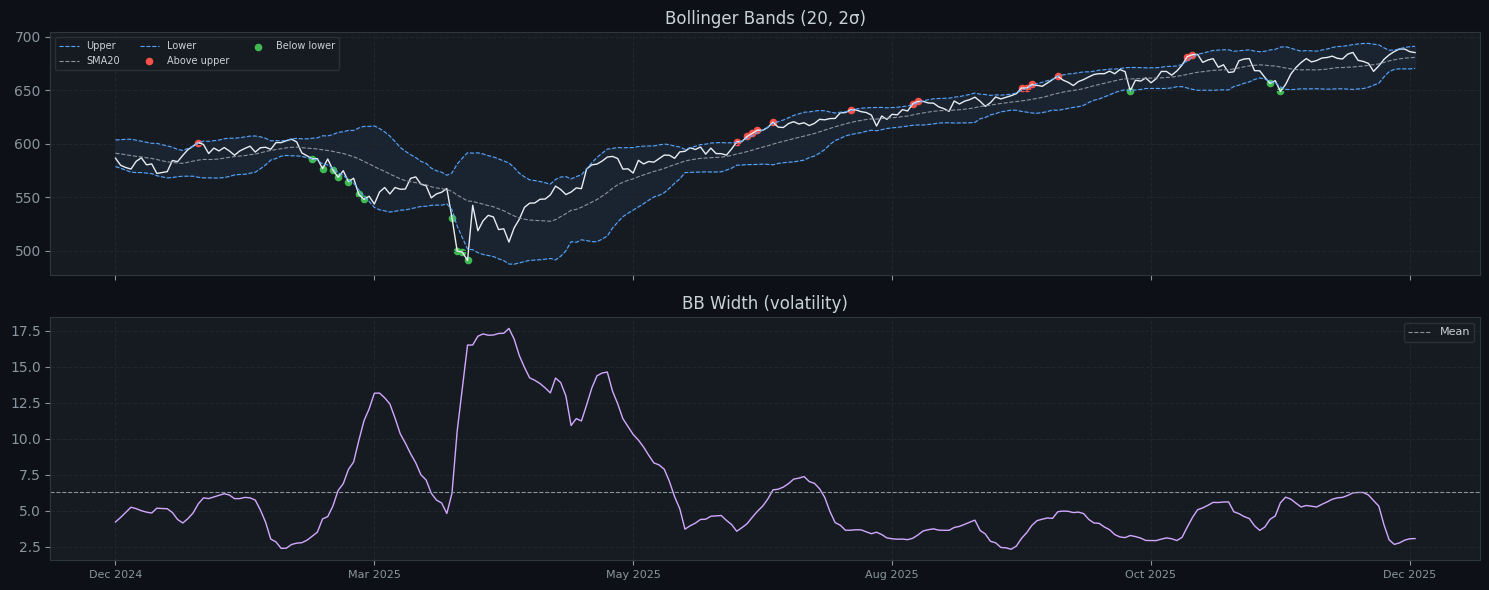

Above upper: 15 days  |  Below lower: 14 days


In [37]:
fig, (ax_p, ax_w) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
ax_p.plot(idx, view['close'],    color='#e6edf3', lw=1)
ax_p.plot(idx, view['bb_upper'], color='#58a6ff', lw=0.8, ls='--', label='Upper')
ax_p.plot(idx, view['bb_mid'],   color='#8b949e', lw=0.8, ls='--', label='SMA20')
ax_p.plot(idx, view['bb_lower'], color='#58a6ff', lw=0.8, ls='--', label='Lower')
ax_p.fill_between(idx, view['bb_upper'], view['bb_lower'], alpha=0.07, color='#58a6ff')
above = view['bb_pct'] > 1.0; below = view['bb_pct'] < 0.0
ax_p.scatter([i for i,m in zip(idx,above) if m], view.loc[above,'close'].values, color='#f85149', s=20, label='Above upper')
ax_p.scatter([i for i,m in zip(idx,below) if m], view.loc[below,'close'].values, color='#3fb950', s=20, label='Below lower')
ax_p.set_title('Bollinger Bands (20, 2σ)'); ax_p.legend(fontsize=7, ncol=3); ax_p.grid(True)
ax_w.plot(idx, view['bb_width'], color='#d2a8ff', lw=1)
ax_w.axhline(view['bb_width'].mean(), color='#8b949e', ls='--', lw=0.8, label='Mean')
ax_w.set_title('BB Width (volatility)'); ax_w.legend(fontsize=8); ax_w.grid(True)
ax_w.set_xticks(tick_pos); ax_w.set_xticklabels(tick_labels, fontsize=8)
plt.tight_layout(); plt.show()
print(f'Above upper: {above.sum()} days  |  Below lower: {below.sum()} days')

### 5.4 OBV Divergence Check

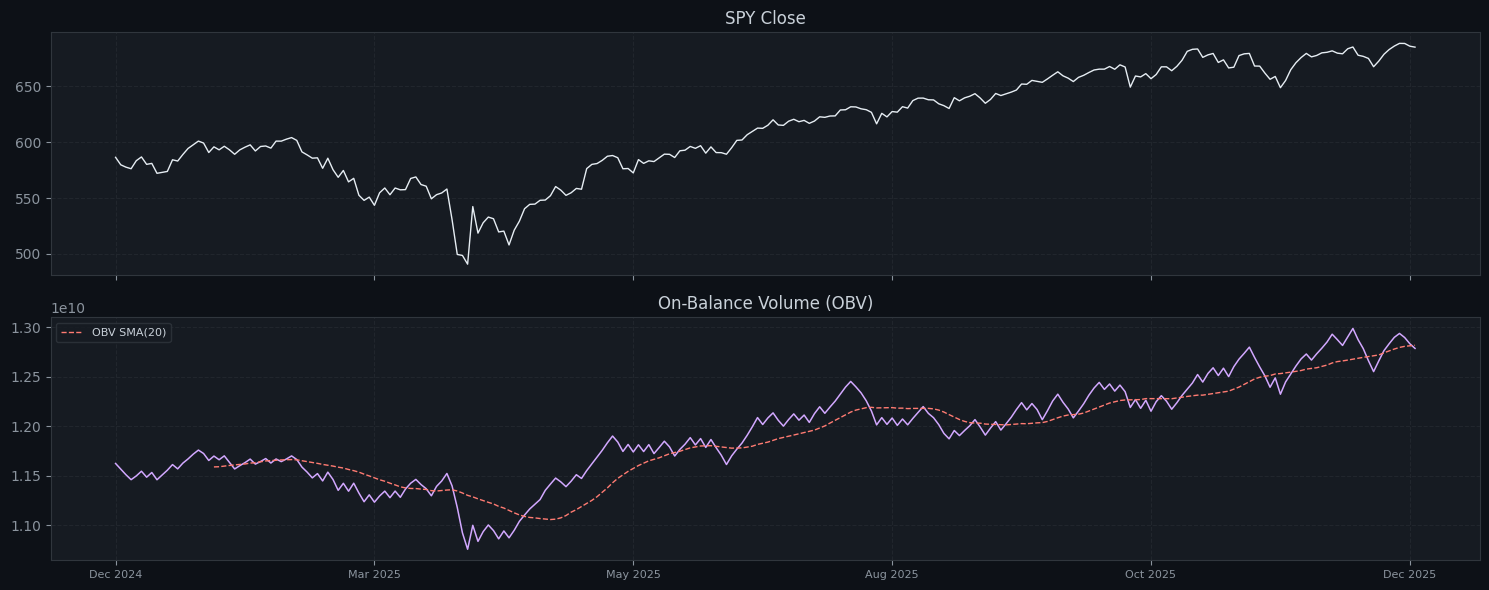

20-day price change: +1.29%  |  20-day OBV change: +0.93%
No divergence


In [38]:
fig, (ax_p, ax_o) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
ax_p.plot(idx, view['close'], color='#e6edf3', lw=1); ax_p.set_title('SPY Close'); ax_p.grid(True)
ax_o.plot(idx, view['obv'], color='#d2a8ff', lw=1.1)
ax_o.plot(idx, view['obv'].rolling(20).mean(), color='#ff7b72', lw=1, ls='--', label='OBV SMA(20)')
ax_o.set_title('On-Balance Volume (OBV)'); ax_o.legend(fontsize=8); ax_o.grid(True)
ax_o.set_xticks(tick_pos); ax_o.set_xticklabels(tick_labels, fontsize=8)
plt.tight_layout(); plt.show()
pc = view['close'].pct_change(20).iloc[-1]
oc = view['obv'].pct_change(20).iloc[-1]
print(f'20-day price change: {pc:+.2%}  |  20-day OBV change: {oc:+.2%}')
if pc>0 and oc<0: print('Bearish divergence: price up, OBV down')
elif pc<0 and oc>0: print('Bullish divergence: price down, OBV up')
else: print('No divergence')

### 5.5 ADX Trend-Strength Regimes

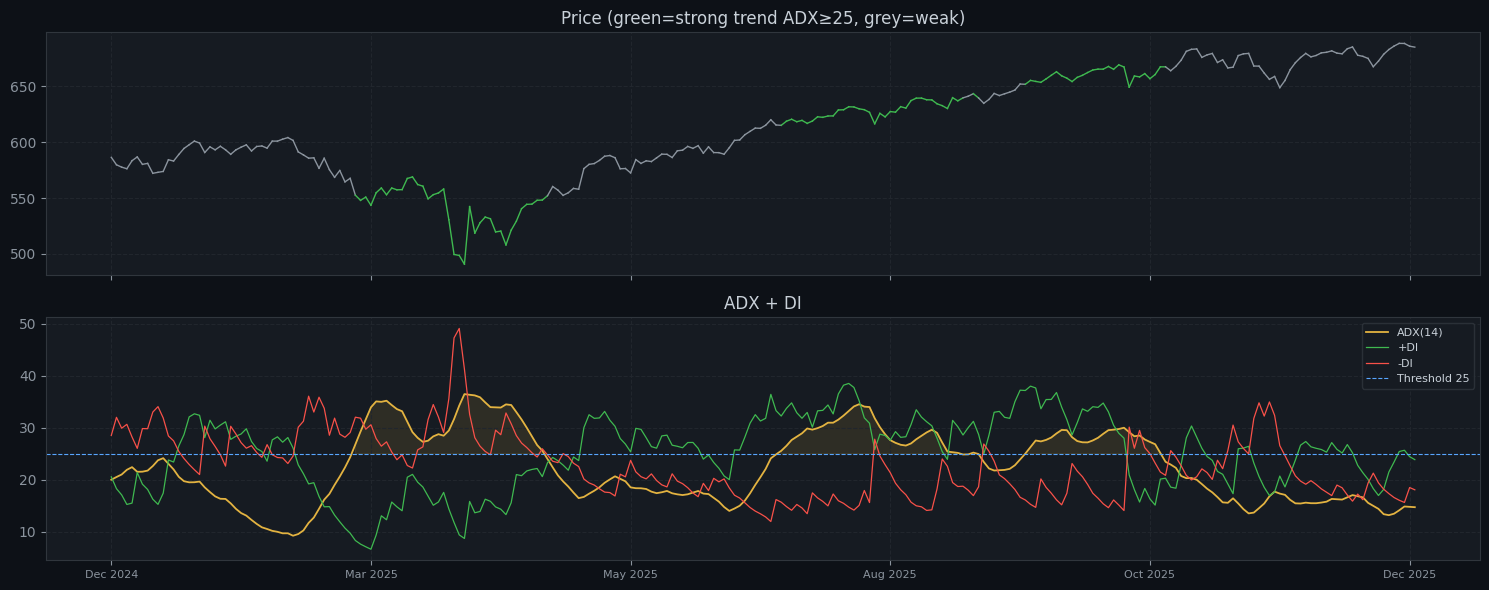

Strong-trend days (ADX≥25): 100/252 (39.7%)


In [39]:
fig, (ax_p, ax_a) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
strong = view['adx'] >= 25
for i in range(len(view)-1):
    c = '#3fb950' if strong.iloc[i] else '#8b949e'
    ax_p.plot([i, i+1], [view['close'].iloc[i], view['close'].iloc[i+1]], color=c, lw=1)
ax_p.set_title('Price (green=strong trend ADX≥25, grey=weak)'); ax_p.grid(True)
ax_a.plot(idx, view['adx'],     color='#e3b341', lw=1.3, label='ADX(14)')
ax_a.plot(idx, view['adx_pos'], color='#3fb950', lw=0.9, label='+DI')
ax_a.plot(idx, view['adx_neg'], color='#f85149', lw=0.9, label='-DI')
ax_a.axhline(25, color='#58a6ff', ls='--', lw=0.8, label='Threshold 25')
ax_a.fill_between(idx, 25, view['adx'], where=(view['adx']>=25), color='#e3b341', alpha=0.12)
ax_a.set_title('ADX + DI'); ax_a.legend(fontsize=8); ax_a.grid(True)
ax_a.set_xticks(tick_pos); ax_a.set_xticklabels(tick_labels, fontsize=8)
plt.tight_layout(); plt.show()
print(f'Strong-trend days (ADX≥25): {strong.sum()}/{len(view)} ({strong.mean()*100:.1f}%)')

### 5.6 Parabolic SAR Signals

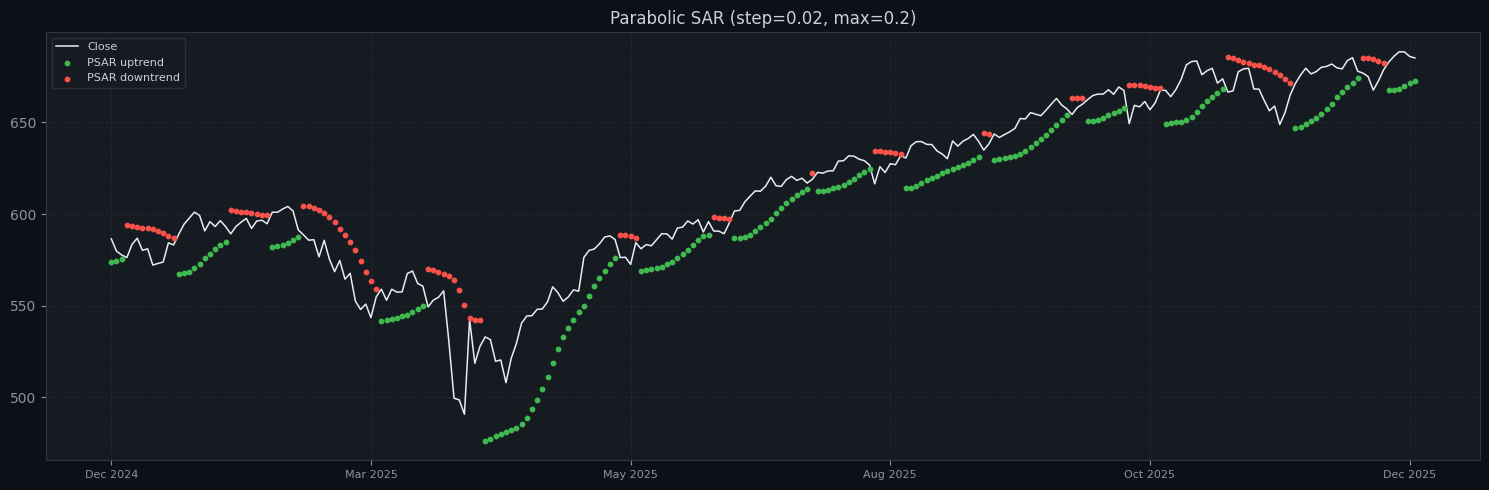

PSAR uptrend: 64.7%  |  downtrend: 35.3%


In [40]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(idx, view['close'], color='#e6edf3', lw=1.1, label='Close')
up_m   = view['psar_up'].notna()
down_m = view['psar_down'].notna()
ax.scatter([i for i,m in zip(idx,up_m)   if m], view.loc[up_m,'psar_up'].values,
           color='#3fb950', s=10, label='PSAR uptrend', zorder=3)
ax.scatter([i for i,m in zip(idx,down_m) if m], view.loc[down_m,'psar_down'].values,
           color='#f85149', s=10, label='PSAR downtrend', zorder=3)
ax.set_title('Parabolic SAR (step=0.02, max=0.2)'); ax.legend(fontsize=8); ax.grid(True)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels, fontsize=8)
plt.tight_layout(); plt.show()
print(f'PSAR uptrend: {up_m.mean()*100:.1f}%  |  downtrend: {down_m.mean()*100:.1f}%')

## 6 — Summary Statistics & Correlation Matrix

In [41]:
summary_cols = ['rsi_14','stoch_k','stoch_d','macd','macd_signal',
                'bb_width','bb_pct','adx','adx_pos','adx_neg']
df[summary_cols].describe().round(3)

,rsi_14,stoch_k,stoch_d,macd,macd_signal,bb_width,bb_pct,adx,adx_pos,adx_neg
count,4010.000,4010.000,4008.000,3998.000,3990.000,4004.000,4004.000,4023.000,4023.000,4023.000
mean,56.270,65.705,65.716,1.037,1.037,6.115,0.616,22.751,25.624,23.183
std,11.426,30.286,27.951,3.195,2.991,3.890,0.321,8.105,7.395,7.326
min,16.803,0.000,0.851,-21.556,-18.040,0.945,-0.473,0.000,0.000,0.000
25%,48.362,42.937,43.516,-0.129,-0.056,3.760,0.393,16.736,20.500,18.093
50%,57.659,75.509,75.705,1.080,1.039,5.220,0.710,21.498,25.930,22.417
75%,64.851,92.440,90.370,2.401,2.360,7.313,0.863,27.796,30.941,27.686
max,87.192,100.000,99.938,12.128,9.607,43.270,1.292,55.202,50.248,66.056


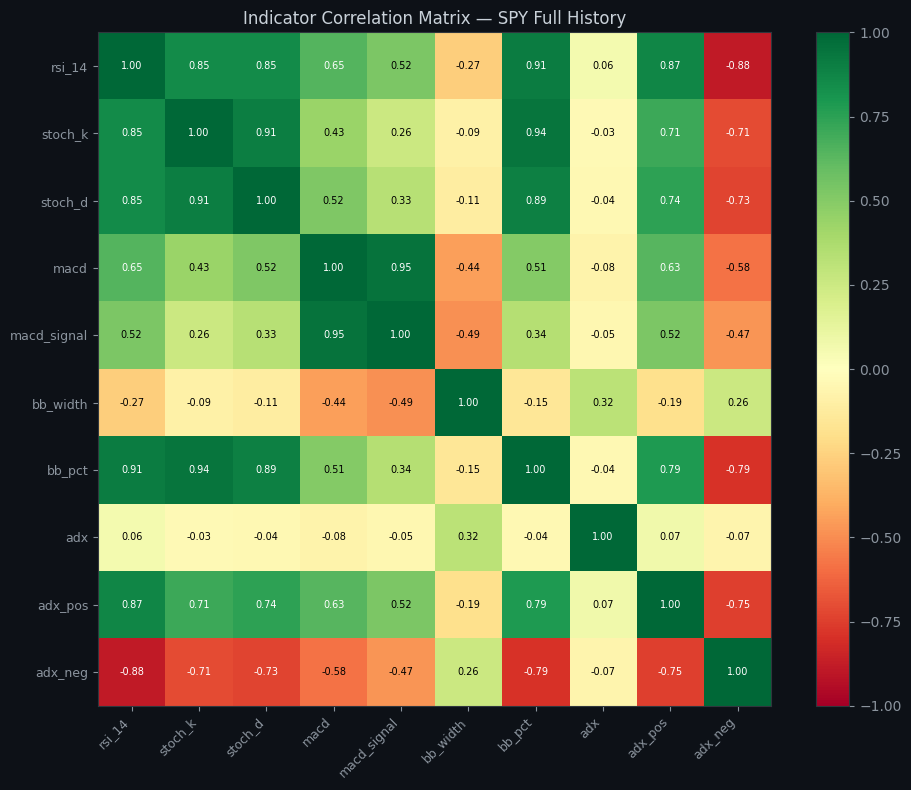

In [42]:
corr_matrix = df[summary_cols].dropna().corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(summary_cols))); ax.set_yticks(range(len(summary_cols)))
ax.set_xticklabels(summary_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(summary_cols, fontsize=9)
for i in range(len(summary_cols)):
    for j in range(len(summary_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(corr_matrix.iloc[i,j])<0.6 else 'white')
ax.set_title('Indicator Correlation Matrix — SPY Full History', fontsize=12)
plt.tight_layout(); plt.show()

## 7 — Key Takeaways

| Indicator | What it tells you | Typical use |
|---|---|---|
| **MACD** | Trend direction + momentum | Enter on crossover, exit on reversal |
| **RSI** | Overbought / oversold momentum | Mean-reversion trades at extremes (30/70) |
| **Stochastic** | Short-term price position in range | Fast reversal signals in ranging markets |
| **Bollinger Bands** | Volatility expansion/contraction | Breakout entries; band-touch reversals |
| **OBV** | Volume confirms price trend | Divergence = early warning of reversal |
| **ADX** | Trend *strength* (not direction) | Filter: only trend-follow when ADX ≥ 25 |
| **PSAR** | Dynamic trailing stop | Flip-dot = trend reversal; stop placement |

In [61]:
df = pd.read_csv('Data/processed/SPY/train.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.drop(columns=['date', 'open','high','low','close','volume', 'tic', 'day'], axis=1)
print(f'Shape: {df.shape}')
# print(f'Date range: {df.date.min().date()}  →  {df.date.max().date()}')
df.tail()

Shape: (2988, 15)


,ret_1d,ret_5d,sma_ratio,vol_20d,vol_ratio,rsi_14,macd_hist,stoch_k,stoch_d,bb_width,bb_pct,obv_ret,adx,adx_di_diff,psar_bull
2983,1.268329,1.583259,1.123651,0.574249,-1.171501,0.446988,0.584343,1.115812,0.944891,0.041706,1.264008,-0.016742,-0.850988,0.847539,0.753322
2984,-0.134811,2.052711,1.020688,0.538192,-1.417662,0.410562,0.793753,0.885818,1.039685,0.180681,1.008659,-0.018815,-0.754578,0.944938,0.753322
2985,0.061711,1.278963,0.965013,0.363478,-1.122414,0.448503,0.894757,0.960169,1.073255,0.234575,0.904108,-0.016788,-0.668577,0.896471,0.753322
2986,-0.317334,0.684888,0.713375,0.298122,-1.021326,0.310609,0.848714,0.778493,0.951012,0.129237,0.702360,-0.018974,-0.581793,0.892917,0.753322
2987,-0.294439,0.281592,0.512168,0.241058,-0.623366,0.182123,0.712789,0.633238,0.859477,0.098994,0.488777,-0.019177,-0.529478,0.764669,0.753322


In [63]:
df.describe().round(4).T

,count,mean,std,min,25%,50%,75%,max
ret_1d,2988.0,-0.0,1.0,-10.3150,-0.3779,0.0099,0.4590,8.4344
ret_5d,2988.0,0.0,1.0,-8.3333,-0.4150,0.0778,0.5264,7.7731
sma_ratio,2988.0,-0.0,1.0,-8.8928,-0.3941,0.1530,0.5713,4.6984
vol_20d,2988.0,-0.0,1.0,-1.1518,-0.5815,-0.2670,0.2737,8.3010
vol_ratio,2988.0,-0.0,1.0,-1.9562,-0.6798,-0.2012,0.4066,7.1131
rsi_14,2988.0,-0.0,1.0,-3.5678,-0.6730,0.1200,0.7393,2.7154
macd_hist,2988.0,0.0,1.0,-7.5567,-0.4233,0.0217,0.4839,6.3307
stoch_k,2988.0,-0.0,1.0,-2.2500,-0.7351,0.3351,0.8743,1.1223
stoch_d,2988.0,0.0,1.0,-2.4151,-0.7877,0.3538,0.8801,1.2177
bb_width,2988.0,-0.0,1.0,-1.2108,-0.5585,-0.2076,0.2743,9.2582


ret_1d            Axes(0.125,0.712609;0.168478x0.167391)
ret_5d         Axes(0.327174,0.712609;0.168478x0.167391)
sma_ratio      Axes(0.529348,0.712609;0.168478x0.167391)
vol_20d        Axes(0.731522,0.712609;0.168478x0.167391)
vol_ratio         Axes(0.125,0.511739;0.168478x0.167391)
rsi_14         Axes(0.327174,0.511739;0.168478x0.167391)
macd_hist      Axes(0.529348,0.511739;0.168478x0.167391)
stoch_k        Axes(0.731522,0.511739;0.168478x0.167391)
stoch_d            Axes(0.125,0.31087;0.168478x0.167391)
bb_width        Axes(0.327174,0.31087;0.168478x0.167391)
bb_pct          Axes(0.529348,0.31087;0.168478x0.167391)
obv_ret         Axes(0.731522,0.31087;0.168478x0.167391)
adx                   Axes(0.125,0.11;0.168478x0.167391)
adx_di_diff        Axes(0.327174,0.11;0.168478x0.167391)
psar_bull          Axes(0.529348,0.11;0.168478x0.167391)
dtype: object

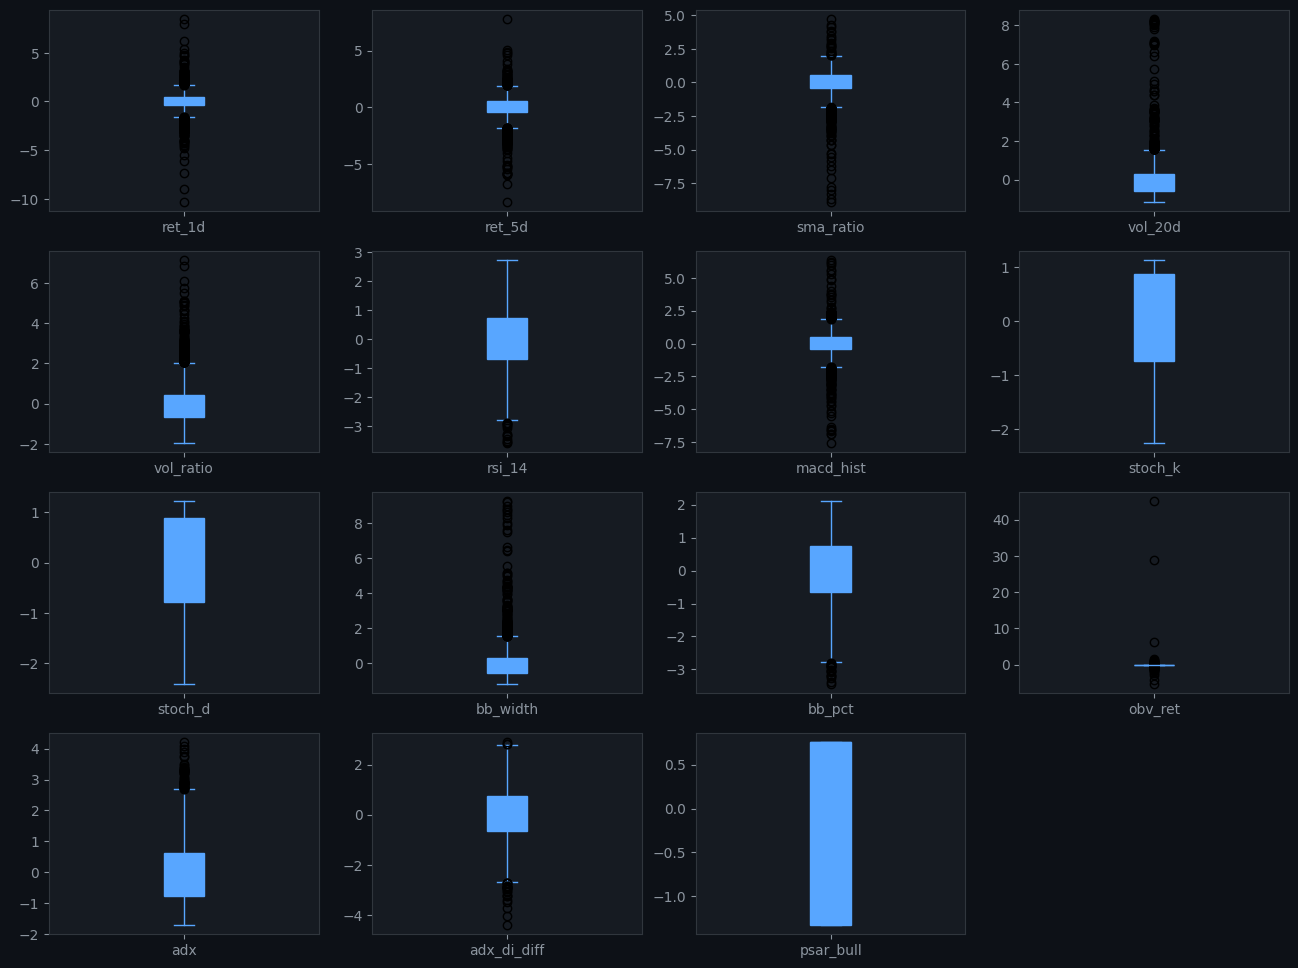

In [64]:
df.plot(kind='box', subplots=True, layout=(4,4), figsize=(16,12), color='#58a6ff', patch_artist=True)

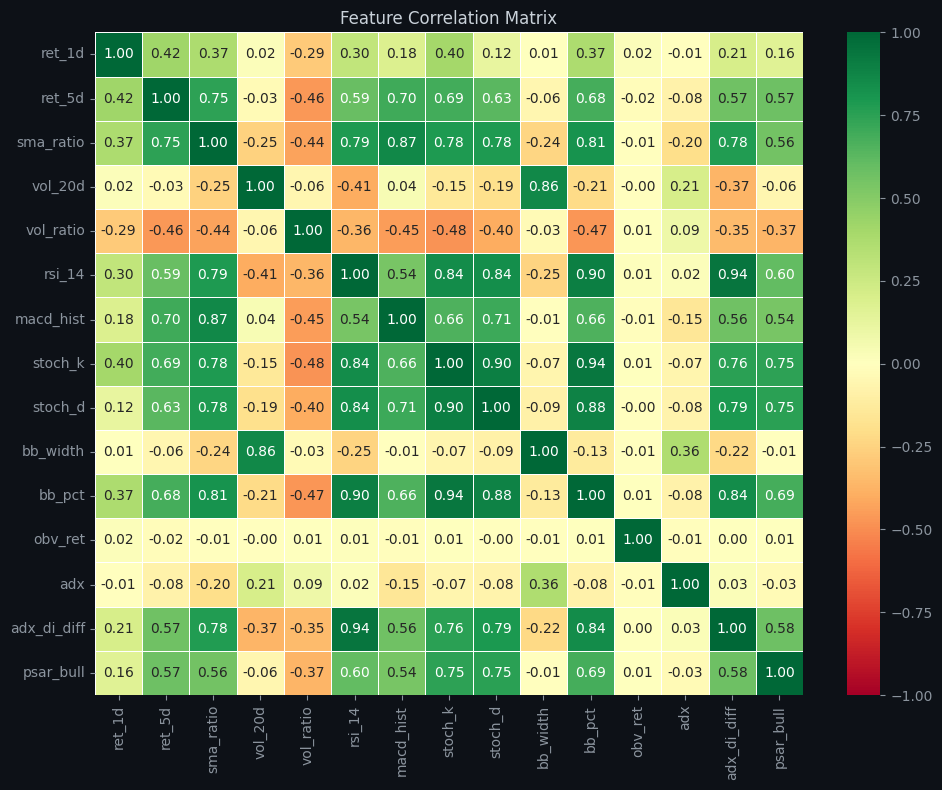

In [66]:
import seaborn as sns
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=12)
plt.tight_layout(); plt.show()  